<a href="https://colab.research.google.com/github/Santicue14/TP-SistemasInteligentes/blob/main/2)_KNN_Trees_metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación (KNN y Árboles de Decisión)
**Dataset:** Insuficiencia cardíaca. Conjunto de datos para la predicción de insuficiencia cardíaca.
Dataset original: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
**Tarea:** El objetivo es clasificar correctamente la enfermedad cardíaca: clase de salida [1: enfermedad cardíaca, 0: normal].

In [ ]:
import pandas as pd
import seaborn as sns
sns.set_style("darkgrid")
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay
from matplotlib import pyplot as plt

In [ ]:
dataset = pd.read_csv("dataset_heart.csv")
dataset.head()

,Age,Sex,ChestPainType,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,289,0,172,N,0.0,Up,0
1,49,F,NAP,180,0,156,N,1.0,Flat,1
2,37,M,ATA,283,0,98,N,0.0,Up,0
3,48,F,ASY,214,0,108,Y,1.5,Flat,1
4,54,M,NAP,195,0,122,N,0.0,Up,0


En el códgio debajo, nos encargamos de utilizar el método get_dummies para justamente ajustar los datos del dataset y con el drop_first nos encargamos de borrar las variables ficticias, asumiendo que por ejemplo Sex_M = 1 es Male, y sino es Female, etc.
También pasamos todo a numérico para entrenar el modelo luego.

In [ ]:
dataset_parse = pd.get_dummies(dataset,
                               columns=['Sex', 'ChestPainType', 'ExerciseAngina', 'ST_Slope'],
                               drop_first=True,
                               dtype=int
                               )

dataset_parse.head()

,Age,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,289,0,172,0.0,0,1,1,0,0,0,0,1
1,49,180,0,156,1.0,1,0,0,1,0,0,1,0
2,37,283,0,98,0.0,0,1,1,0,0,0,0,1
3,48,214,0,108,1.5,1,0,0,0,0,1,1,0
4,54,195,0,122,0.0,0,1,0,1,0,0,0,1


Preparamos nuestros X e y en base al dataset parseado, y no al original.
Seteamos la variable prc_test como el porcentaje que será tomado para conjuntos de datos de prueba y de entrenamiento y luego con train_test_split mapeamos esos datos.

In [ ]:
X = dataset_parse.iloc[:, :-1]
y = dataset_parse.iloc[:, -1]
prc_test = 0.2

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=prc_test)

Instanciamos los 3 modelos con distintos K para probar distintas h(x).

In [ ]:
modeloK3 = KNeighborsClassifier(n_neighbors=3)
modeloK5 = KNeighborsClassifier(n_neighbors=5)
modeloK11 = KNeighborsClassifier(n_neighbors=11)

Acá entrenamos los 3 modelos instanciados previamente, todos con el mismo set de datos de entrenamiento

In [ ]:
modeloK3.fit(X_train, y_train)
modeloK5.fit(X_train, y_train)
modeloK11.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

En el bloque de abajo, calculamos el porcentaje de precisión utilizando accuracy_score de sklearn y también calculamos la matriz de confusión, que próximamente pondremos a la vista

In [ ]:
precisionModeloK3 = accuracy_score(y_test, modeloK3.predict(X_test))
precisionModeloK5 = accuracy_score(y_test, modeloK5.predict(X_test))
precisionModeloK11 = accuracy_score(y_test, modeloK11.predict(X_test))

matrizModeloK3 = confusion_matrix(y_test, modeloK3.predict(X_test))
matrizModeloK5 = confusion_matrix(y_test, modeloK5.predict(X_test))
matrizModeloK11 = confusion_matrix(y_test, modeloK11.predict(X_test))


Mapeamos esta matriz de confusión utlizando matplotlib para verla de manera gráfica y en el título le ponemos el % de precisión de cada modelo según los hiperpárametros

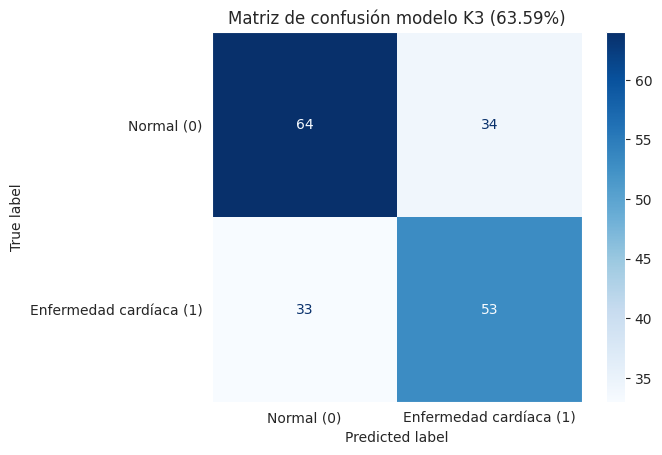

In [ ]:
graficoK3 = ConfusionMatrixDisplay(confusion_matrix=matrizModeloK3, display_labels=['Normal (0)','Enfermedad cardíaca (1)'])
graficoK3.plot(cmap='Blues',values_format='d')
plt.title(f"Matriz de confusión modelo K3 ({round(precisionModeloK3*100,2)}%)")
plt.grid(False)
plt.show()

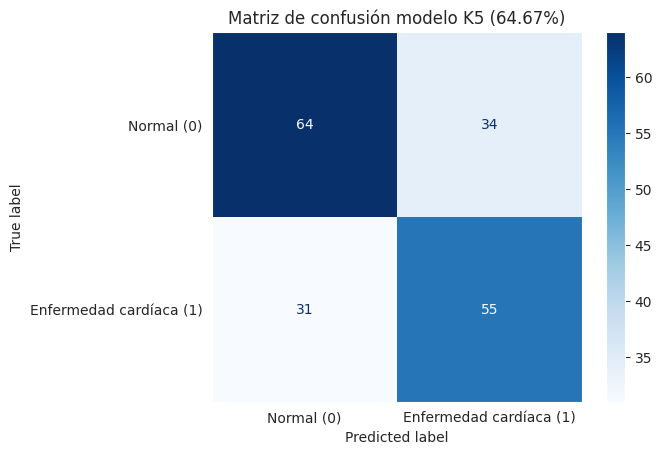

In [ ]:

graficoK5 = ConfusionMatrixDisplay(confusion_matrix=matrizModeloK5,display_labels=['Normal (0)','Enfermedad cardíaca (1)'])
graficoK5.plot(cmap='Blues',values_format='d')
plt.title(f"Matriz de confusión modelo K5 ({round(precisionModeloK5*100,2)}%)")
plt.grid(False)
plt.show()

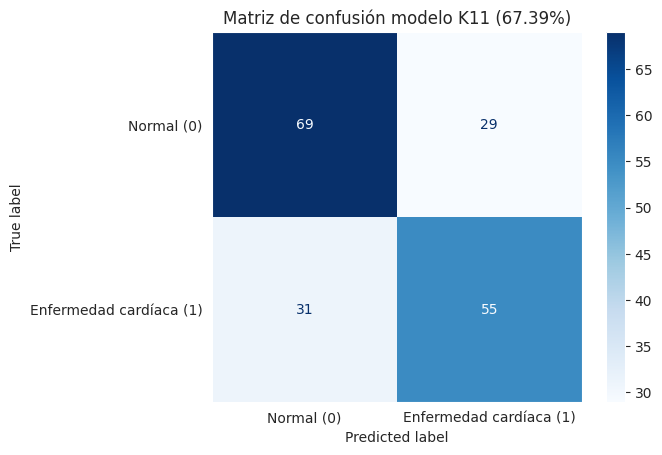

In [ ]:
graficoK11 = ConfusionMatrixDisplay(confusion_matrix=matrizModeloK11, display_labels=['Normal (0)','Enfermedad cardíaca (1)'])
graficoK11.plot(cmap='Blues',values_format='d')
plt.title(f"Matriz de confusión modelo K11 ({round(precisionModeloK11*100,2)}%)")
plt.grid(False)
plt.show()

A continuación, utilizando el dataset parseado que realizamos previamente, haremos uso de árboles de decisión y compararemos los modelos de  KNN vs. los modelos de Árboles de decisión para ver quien tiene una mejor exactitud

In [ ]:
from sklearn.tree import DecisionTreeClassifier,plot_tree # Importo la librerías que faltaban
from sklearn.tree import plot_tree

Instancio y entreno los modelos con el dataset parseado de antes, probaremos con una profundidad de 3, 5 y 10 y ver quien se comporta mejor

In [ ]:
modeloArbolD3 = DecisionTreeClassifier(max_depth=3)
modeloArbolD5 = DecisionTreeClassifier(max_depth=5)
modeloArbolD10 = DecisionTreeClassifier(max_depth=10)

modeloArbolD3.fit(X_train, y_train)
modeloArbolD5.fit(X_train, y_train)
modeloArbolD10.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

Estilamos el plot para que se vea bien el arbolito

In [ ]:
plt.figure(figsize=(30,30))

<Figure size 3000x3000 with 0 Axes>

<Figure size 3000x3000 with 0 Axes>

Ploteamos los modelos para ver como quedaron

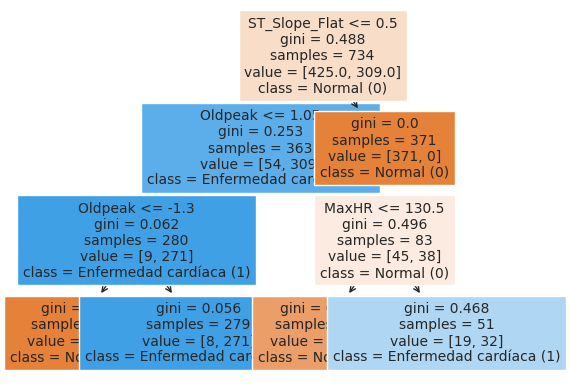

In [ ]:
plot_tree(modeloArbolD3, feature_names=X.columns,
          class_names=['Normal (0)','Enfermedad cardíaca (1)'],
          filled=True,
          fontsize=10)

plt.show()

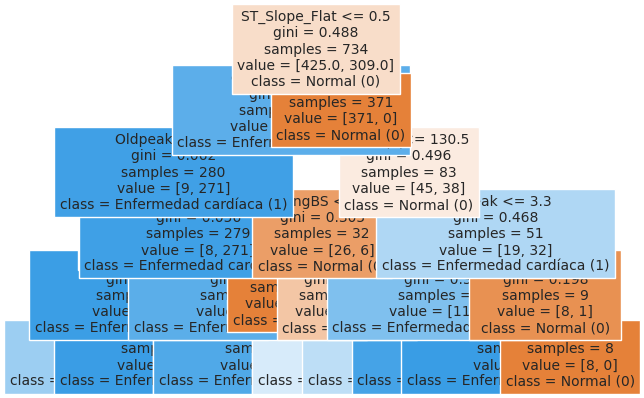

In [ ]:
plot_tree(modeloArbolD5, feature_names=X.columns,
          class_names=['Normal (0)','Enfermedad cardíaca (1)'],
          filled=True,
          fontsize=10)

plt.show()

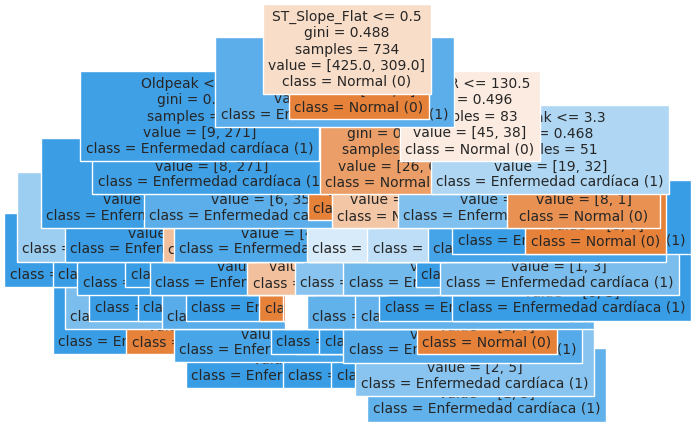

In [ ]:
plot_tree(modeloArbolD10, feature_names=X.columns,
          class_names=['Normal (0)','Enfermedad cardíaca (1)'],
          filled=True,
          fontsize=10)

plt.show()

Calculamos precisión y matrices de confusión de los modelos de árboles

In [ ]:
precisionModeloD3 = accuracy_score(y_test, modeloArbolD3.predict(X_test))
precisionModeloD5 = accuracy_score(y_test, modeloArbolD5.predict(X_test))
precisionModeloD10 = accuracy_score(y_test, modeloArbolD10.predict(X_test))

matrizModeloD3 = confusion_matrix(y_test, modeloArbolD3.predict(X_test))
matrizModeloD5 = confusion_matrix(y_test, modeloArbolD5.predict(X_test))
matrizModeloD10 = confusion_matrix(y_test, modeloArbolD10.predict(X_test))

Ploteamos para visualizar qué tan bien dieron los modelos, en el título se puede ver la precisión que tuvieron contra los datos de prueba

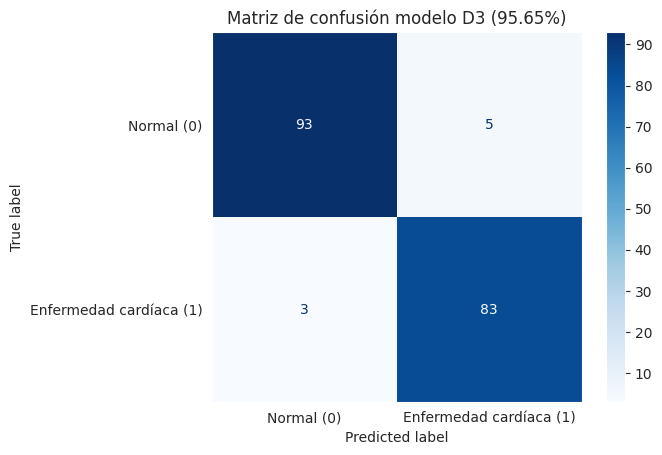

In [ ]:
graficoD3 = ConfusionMatrixDisplay(confusion_matrix=matrizModeloD3, display_labels=['Normal (0)','Enfermedad cardíaca (1)'])
graficoD3.plot(cmap='Blues',values_format='d')
plt.title(f"Matriz de confusión modelo D3 ({round(precisionModeloD3*100,2)}%)")
plt.grid(False)
plt.show()

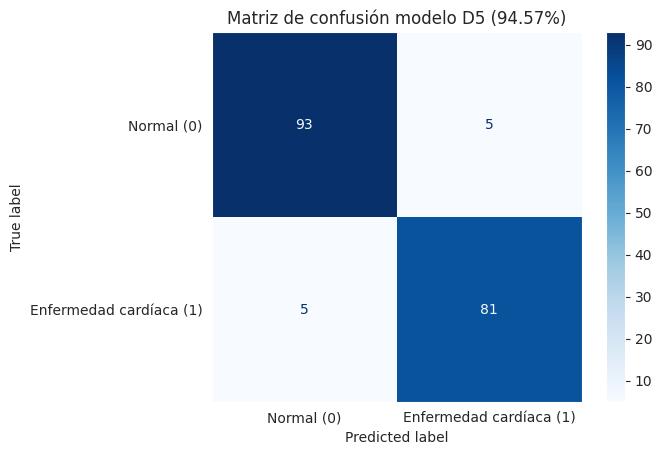

In [ ]:
graficoD5 = ConfusionMatrixDisplay(confusion_matrix=matrizModeloD5, display_labels=['Normal (0)','Enfermedad cardíaca (1)'])
graficoD5.plot(cmap='Blues',values_format='d')
plt.title(f"Matriz de confusión modelo D5 ({round(precisionModeloD5*100,2)}%)")
plt.grid(False)
plt.show()

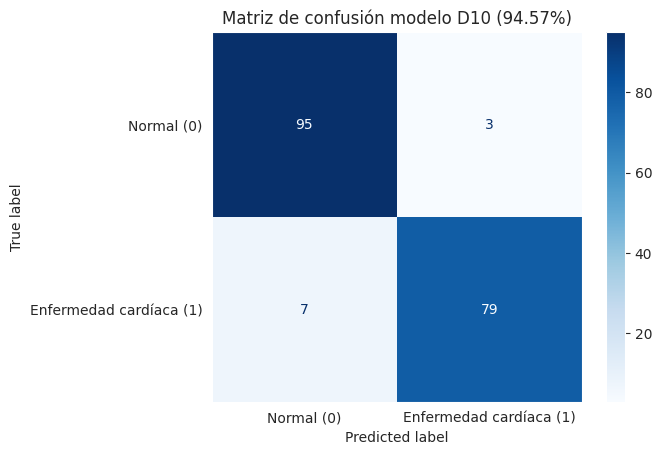

In [ ]:
graficoD10 = ConfusionMatrixDisplay(confusion_matrix=matrizModeloD10, display_labels=['Normal (0)','Enfermedad cardíaca (1)'])
graficoD10.plot(cmap='Blues',values_format='d')
plt.title(f"Matriz de confusión modelo D10 ({round(precisionModeloD10*100,2)}%)")
plt.grid(False)
plt.show()

Entre los árboles que se mapearon, el más confiable es el que tiene como hiperparámetro max_depth = 3, es decir, con una profundidad de 3, el árbol puede dar buenos resultados si lo probamos contra lo que es el conjunto de prueba. Respondiendo la pregunta, de qué pasa si el árbol es muy profundo, esto generaliza mucho, como es el caso del `modeloArbolD10` que tiene una accuracy redondeada del 94,57% vs la 95,65% del `modeloArbolD3`.

## Análisis Comparativo:

### Comparando las matrices de confusión de ambos algoritmos, ¿hubo alguna clase que a los modelos les costara más predecir correctamente?

Por lo que vemos en el código de abajo, no. No hubo una clase que costó predecir más que la otra, los errores se encuentran equilibrados.

**En KNN:** tuvimos 97 falsos positivos y 95 falsos negativos (sumados entre todas las hipótesis que probamos), es decir, que son resultados dentro de todo aceptables.

**En Árboles de decisión:** tuvimos 13 falsos positivos y 15 falsos negativos (sumados entre todas las hipótesis que probamos), es decir, que también nos mantuvimos equilibrados.



In [ ]:
# 1. Sumamos todas las matrices de la familia KNN
matriz_total_knn = matrizModeloK3 + matrizModeloK5 + matrizModeloK11

# 2. Sumamos todas las matrices de la familia de Árboles de Decisión
matriz_total_arboles = matrizModeloD3 + matrizModeloD5 + matrizModeloD10

# [0, 0]: Verdaderos Negativos (TN)
# [0, 1]: Falsos Positivos (FP)
# [1, 0]: Falsos Negativos (FN)
# [1, 1]: Verdaderos Positivos (TP)

print("MODELOS KNN")
print(f"Total Falsos Positivos: {matriz_total_knn[0, 1]}")
print(f"Total Falsos Negativos: {matriz_total_knn[1, 0]}")

print("\nÁRBOLES DE DECISIÓN")
print(f"Total Falsos Positivos: {matriz_total_arboles[0, 1]}")
print(f"Total Falsos Negativos: {matriz_total_arboles[1, 0]}")

MODELOS KNN
Total Falsos Positivos: 97
Total Falsos Negativos: 95

ÁRBOLES DE DECISIÓN
Total Falsos Positivos: 13
Total Falsos Negativos: 15


### ¿Cuál de los dos algoritmos (KNN o Árboles de Decisión) arrojó mejores resultados para este problema en particular?

Por una diferencia bastante grande, los árboles de decisión, tanto de 3, 5 o 10 de profundidad arrojaron muchísimos mejores resultados que KNN.
Tengamos en cuenta que además, siendo que hay que predecir si alguien está enfermo o no, siempre tomaremos como prioridad reducir el número de falsos negativos.